# Tugas - Klasifikasi dengan Artificial Neural Network (ANN)

| Nama | NRP |
|------|-----|
| Pranaja Adyatma Budiman | 5054251009 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model ANN (Multi-Layer Perceptron) Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja ANN secara praktik, khususnya:
1. Perbedaan hasil antar fungsi aktivasi (ReLU, Tanh, Logistic/Sigmoid)
2. Pengaruh ukuran arsitektur (`hidden_layer_sizes`) dan jumlah iterasi terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model ANN dengan arsitektur dasar.
   - Lakukan eksperimen fungsi aktivasi dan regularisasi arsitektur.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [2]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Pengaturan visualisasi
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.titlesize'] = 12

In [3]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()



,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


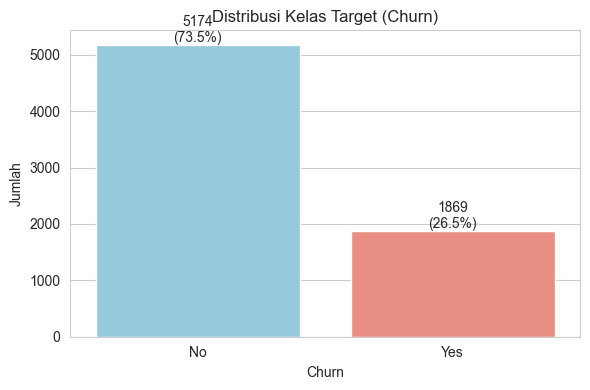

In [6]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.

# Distribusi kelas target
print(df['Churn'].value_counts())
print((df['Churn'].value_counts(normalize=True)*100).round(2))

plt.figure(figsize=(6,4))
ax = sns.countplot(x='Churn', data=df, hue='Churn', palette=['skyblue','salmon'], legend=False)

# anotasi jumlah + persen di atas bar
total = len(df)
for p in ax.patches:
    count = int(p.get_height())
    pct = count/total*100
    ax.annotate(f'{count}\n({pct:.1f}%)',
                (p.get_x()+p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.title('Distribusi Kelas Target (Churn)')
plt.xlabel('Churn')
plt.ylabel('Jumlah')
plt.tight_layout()
plt.show()

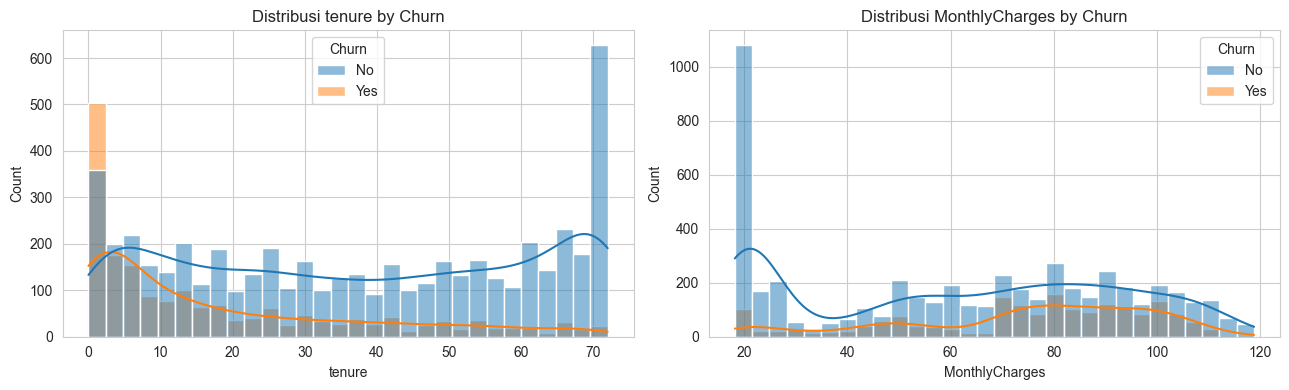

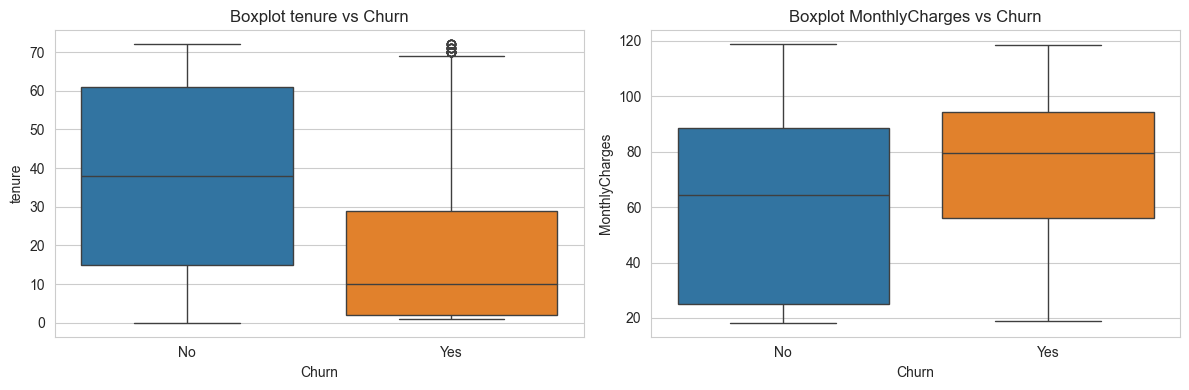

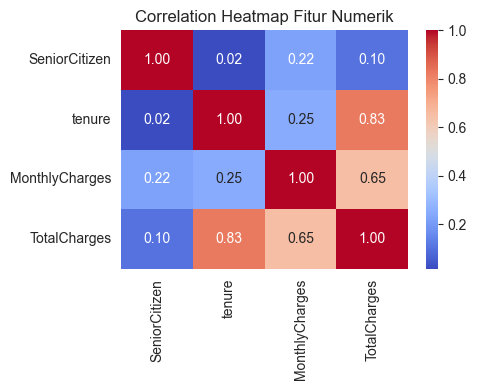

In [7]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau correlation heatmap), dibedakan berdasarkan kelas target.

# 1. Histogram tenure & MonthlyCharges dibedakan Churn
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, bins=30, ax=axes[0])
axes[0].set_title('Distribusi tenure by Churn')
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, bins=30, ax=axes[1])
axes[1].set_title('Distribusi MonthlyCharges by Churn')
plt.tight_layout()
plt.show()

# 2. Boxplot dibedakan Churn
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(x='Churn', y='tenure', data=df, hue='Churn', legend=False, ax=axes[0])
axes[0].set_title('Boxplot tenure vs Churn')
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, hue='Churn', legend=False, ax=axes[1])
axes[1].set_title('Boxplot MonthlyCharges vs Churn')
plt.tight_layout()
plt.show()

# 3. Correlation heatmap fitur numerik
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
num_cols = ['SeniorCitizen','tenure','MonthlyCharges','TotalCharges']
plt.figure(figsize=(5,4))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap Fitur Numerik')
plt.tight_layout()
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

In [8]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.

# Cek missing value: NaN + string kosong/spasi
print(df.isnull().sum()[df.isnull().sum() > 0])
print((df == ' ').sum().sort_values(ascending=False).head())
print((df == '').sum().sum())

# TotalCharges bertipe object karena ada ' ' -> konversi ke numerik
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"% missing: {df.isnull().sum().sum()/len(df)*100:.3f}%")

# Lihat pola baris yang missing
print(df[df['TotalCharges'].isnull()][['tenure','MonthlyCharges','TotalCharges','Churn']])

TotalCharges    11
dtype: int64
customerID       0
gender           0
SeniorCitizen    0
Partner          0
Dependents       0
dtype: int64
0
TotalCharges    11
dtype: int64
% missing: 0.156%
      tenure  MonthlyCharges  TotalCharges Churn
488        0           52.55           NaN    No
753        0           20.25           NaN    No
936        0           80.85           NaN    No
1082       0           25.75           NaN    No
1340       0           56.05           NaN    No
3331       0           19.85           NaN    No
3826       0           25.35           NaN    No
4380       0           20.00           NaN    No
5218       0           19.70           NaN    No
6670       0           73.35           NaN    No
6754       0           61.90           NaN    No


In [9]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).

# customerID = ID unik -> drop, tidak prediktif
# Target: Yes/No -> 1/0
df = df.drop(columns=['customerID'])
df['Churn'] = df['Churn'].map({'No':0, 'Yes':1})

# TotalCharges sudah dikonversi ke numerik di cell sebelumnya
numeric_features = ['SeniorCitizen','tenure','MonthlyCharges','TotalCharges']
categorical_features = ['gender','Partner','Dependents','PhoneService','MultipleLines',
  'InternetService','OnlineSecurity','OnlineBackup','DeviceProtection',
  'TechSupport','StreamingTV','StreamingMovies','Contract',
  'PaperlessBilling','PaymentMethod']

In [10]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.

# X = semua kolom kecuali target, y = Churn (sudah 0/1)
X = df.drop(columns=['Churn'])
y = df['Churn']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(y_train.value_counts(normalize=True).round(4))
print(y_test.value_counts(normalize=True).round(4))


X_train: (5634, 19), X_test: (1409, 19)
Churn
0    0.7346
1    0.2654
Name: proportion, dtype: float64
Churn
0    0.7346
1    0.2654
Name: proportion, dtype: float64


**Catatan penting:** Sama seperti SVM, ANN juga menghitung penjumlahan berbobot dari fitur-fiturnya, sehingga fitur dengan rentang nilai besar bisa mendominasi proses training dan membuat konvergensi lebih lambat atau tidak stabil. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [11]:
# Lakukan feature scaling (StandardScaler) pada fitur numerik.
# fit_transform pada X_train, transform saja pada X_test.

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

numeric_features = ['SeniorCitizen','tenure','MonthlyCharges','TotalCharges']

# 1. Imputasi dulu (median dari TRAIN saja, karena TotalCharges ada 11 NaN)
imputer = SimpleImputer(strategy='median')
X_train_num = imputer.fit_transform(X_train[numeric_features])
X_test_num  = imputer.transform(X_test[numeric_features])

# 2. Scaling: fit HANYA di train
scaler = StandardScaler()
X_train_scaled_num = scaler.fit_transform(X_train_num)
X_test_scaled_num  = scaler.transform(X_test_num)

print("mean train (~0):", X_train_scaled_num.mean(axis=0).round(4))
print("std train (=1):", X_train_scaled_num.std(axis=0).round(4))

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer([
  ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                    ('sc', StandardScaler())]), numeric_features),
  ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                    ('oh', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
   categorical_features)
])

X_train_proc = preprocessor.fit_transform(X_train) # fit 1x di train
X_test_proc = preprocessor.transform(X_test)       # transform saja
print(X_train_proc.shape, X_test_proc.shape)

mean train (~0): [ 0. -0. -0. -0.]
std train (=1): [1. 1. 1. 1.]
(5634, 45) (1409, 45)


# 3. Eksperimen Model

## 3.1 ANN dengan Arsitektur Dasar

Bangun model MLPClassifier sederhana dengan satu hidden layer sebagai baseline.

In [12]:
# Inisialisasi dan latih model MLPClassifier dengan satu hidden layer (misalnya hidden_layer_sizes=(10,))
# dan activation='relu' menggunakan train set (yang sudah discaling).


from sklearn.neural_network import MLPClassifier

# Baseline: 1 hidden layer isi 10 neuron, aktivasi ReLU
mlp_base = MLPClassifier(hidden_layer_sizes=(10,), activation='relu',
                         max_iter=500, random_state=42, verbose=False)

mlp_base.fit(X_train_proc, y_train)  # X_train_proc = hasil preprocessor (sudah discaling)

print(f"n_iter aktual: {mlp_base.n_iter_}, loss akhir: {mlp_base.loss_:.4f}")
print(f"train acc: {mlp_base.score(X_train_proc, y_train):.4f}")

n_iter aktual: 248, loss akhir: 0.3928
train acc: 0.8223


In [13]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.

y_pred_base = mlp_base.predict(X_test_proc)

print(y_pred_base[:10])
print(pd.Series(y_pred_base).value_counts())
print(pd.Series(y_pred_base).value_counts(normalize=True).round(4))

[0 1 0 0 0 1 0 0 0 0]
0    1093
1     316
Name: count, dtype: int64
0    0.7757
1    0.2243
Name: proportion, dtype: float64


## 3.2 Eksperimen Fungsi Aktivasi

Fungsi aktivasi menentukan bagaimana neuron "mengaktivasikan" keluarannya dan memungkinkan model mempelajari pola non-linear. Bandingkan beberapa pilihan fungsi aktivasi yang tersedia di scikit-learn.

In [14]:
# Latih beberapa model MLPClassifier dengan arsitektur yang sama, tetapi activation berbeda:
# 'relu', 'tanh', dan 'logistic'.
# Gunakan hyperparameter lain yang sama (hidden_layer_sizes, max_iter, random_state) agar perbandingan adil.

activations = ['relu', 'tanh', 'logistic']
models_act = {}

for act in activations:
    clf = MLPClassifier(hidden_layer_sizes=(10,), activation=act,
                        max_iter=500, random_state=42)
    clf.fit(X_train_proc, y_train)
    models_act[act] = clf
    print(f"{act}: n_iter={clf.n_iter_}, loss={clf.loss_:.4f}")

relu: n_iter=248, loss=0.3928
tanh: n_iter=340, loss=0.3820
logistic: n_iter=174, loss=0.4065


In [15]:
# Hitung dan bandingkan akurasi test set dari ketiga fungsi aktivasi tersebut.
# Sajikan dalam tabel perbandingan.

from sklearn.metrics import accuracy_score
import pandas as pd

rows = []
for act, clf in models_act.items():
    acc_test = accuracy_score(y_test, clf.predict(X_test_proc))
    acc_train = accuracy_score(y_train, clf.predict(X_train_proc))
    rows.append({'activation': act, 'train_acc': round(acc_train,4),
                 'test_acc': round(acc_test,4), 'n_iter': clf.n_iter_,
                 'loss': round(clf.loss_,4)})

df_act = pd.DataFrame(rows).sort_values('test_acc', ascending=False)
print(df_act.to_string(index=False))

activation  train_acc  test_acc  n_iter   loss
  logistic     0.8085    0.8013     174 0.4065
      relu     0.8223    0.7956     248 0.3928
      tanh     0.8191    0.7857     340 0.3820


## 3.3 Eksperimen Regularisasi: Pengaruh Ukuran Arsitektur terhadap Overfitting

Semakin besar/dalam arsitektur ANN (jumlah neuron dan hidden layer), semakin besar kapasitas model untuk menghafal data training. Pada bagian ini kalian akan mengamati bagaimana perubahan ukuran arsitektur memengaruhi akurasi training dan testing.

In [16]:
# Latih beberapa model MLPClassifier dengan variasi hidden_layer_sizes,
# misalnya (2,), (5,), (10,), (50,), (100, 50).
# Gunakan activation terbaik dari hasil eksperimen 3.2, dan hyperparameter lain yang sama.

# Ambil aktivasi terbaik dari eksperimen 3.2 secara otomatis
best_act = df_act.sort_values('test_acc', ascending=False).iloc[0]['activation']
print(f"activation terbaik: {best_act}")

arch_list = [(2,), (5,), (10,), (50,), (100, 50)]
models_arch = {}

for h in arch_list:
    clf = MLPClassifier(hidden_layer_sizes=h, activation=best_act,
                        max_iter=500, random_state=42)
    clf.fit(X_train_proc, y_train)
    models_arch[str(h)] = clf
    print(f"{h}: n_iter={clf.n_iter_}, loss={clf.loss_:.4f}")


activation terbaik: logistic
(2,): n_iter=224, loss=0.4137
(5,): n_iter=240, loss=0.4079
(10,): n_iter=174, loss=0.4065
(50,): n_iter=189, loss=0.4071
(100, 50): n_iter=500, loss=0.3634


c:\Users\pranaja\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [17]:
# Hitung akurasi pada train set dan test set untuk setiap arsitektur yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.

from sklearn.metrics import accuracy_score

arch_labels, train_accs, test_accs = [], [], []
for label, clf in models_arch.items():
    acc_tr = accuracy_score(y_train, clf.predict(X_train_proc))
    acc_te = accuracy_score(y_test, clf.predict(X_test_proc))
    arch_labels.append(label)
    train_accs.append(acc_tr)
    test_accs.append(acc_te)

import pandas as pd
df_arch = pd.DataFrame({
  'arch': arch_labels, 'train_acc': train_accs, 'test_acc': test_accs})
print(df_arch.to_string(index=False))

     arch  train_acc  test_acc
     (2,)   0.805822  0.801987
     (5,)   0.807064  0.797019
    (10,)   0.808484  0.801278
    (50,)   0.812389  0.800568
(100, 50)   0.834576  0.782825


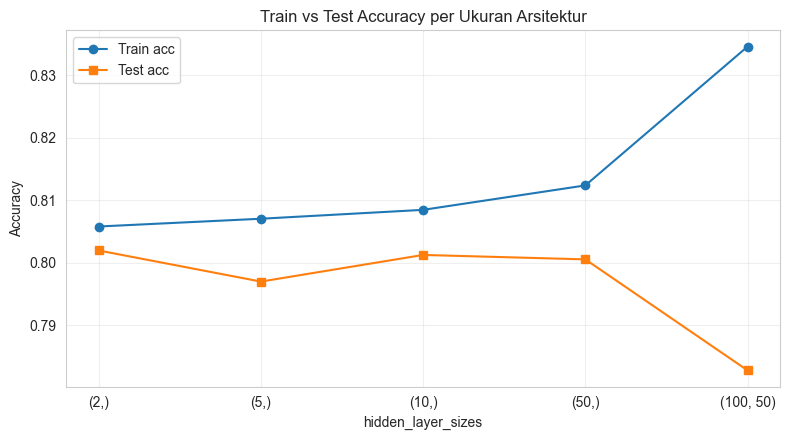

In [18]:
# Plot grafik akurasi training vs testing terhadap ukuran arsitektur dalam satu chart.
# Amati pada arsitektur seberapa besar model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).


x = range(len(arch_labels))
plt.figure(figsize=(8,4.5))
plt.plot(x, train_accs, marker='o', label='Train acc')
plt.plot(x, test_accs, marker='s', label='Test acc')
plt.xticks(x, arch_labels)
plt.xlabel('hidden_layer_sizes')
plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy per Ukuran Arsitektur')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Evaluasi Model

In [19]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model dengan performa terbaik dari tiap eksperimen (3.2 dan 3.3).
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Model terbaik 3.2 = test_acc tertinggi di df_act
best_act_name = df_act.sort_values('test_acc', ascending=False).iloc[0]['activation']
clf_32 = models_act[best_act_name]

# Model terbaik 3.3 = test_acc tertinggi di df_arch
best_arch_label = df_arch.sort_values('test_acc', ascending=False).iloc[0]['arch']
clf_33 = models_arch[best_arch_label]

def scores(clf):
    yp = clf.predict(X_test_proc)
    return [accuracy_score(y_test, yp),
            precision_score(y_test, yp),
            recall_score(y_test, yp),
            f1_score(y_test, yp)]

df_eval = pd.DataFrame([
  [f"3.2-{best_act_name}{ (10,) }"] + scores(clf_32),
  [f"3.3-{best_act_name}{best_arch_label}"] + scores(clf_33)],
  columns=['model','accuracy','precision','recall','f1']).round(4)
print(df_eval.to_string(index=False))

# simpan untuk cell berikutnya
best_clf = clf_33 if df_arch.sort_values('test_acc', ascending=False).iloc[0]['test_acc'] >= df_act['test_acc'].max() else clf_32
print(f"\nbest overall: {df_eval.sort_values('f1', ascending=False).iloc[0]['model']}")

            model  accuracy  precision  recall     f1
3.2-logistic(10,)    0.8013     0.6516  0.5401 0.5906
 3.3-logistic(2,)    0.8020     0.6644  0.5134 0.5792

best overall: 3.2-logistic(10,)


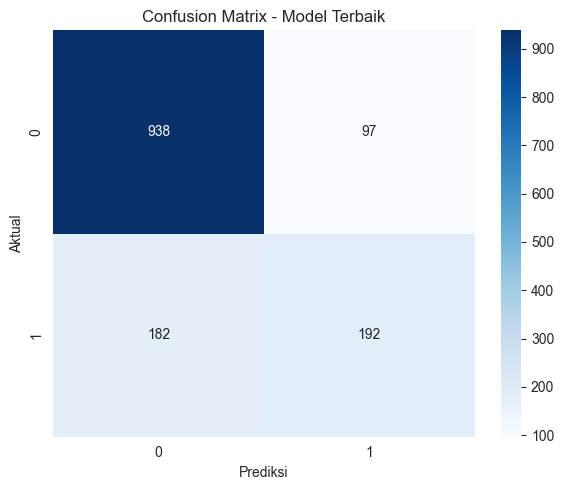

In [20]:
from sklearn.metrics import confusion_matrix

y_pred_best = best_clf.predict(X_test_proc)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix - Model Terbaik')
plt.tight_layout()
plt.show()

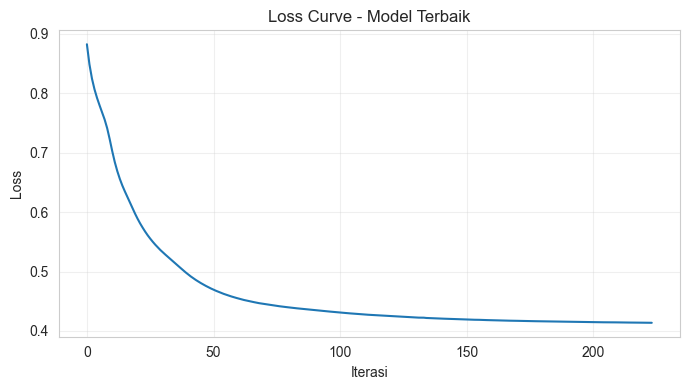

In [23]:
# Plot loss curve dari model dengan performa terbaik (atribut model.loss_curve_).
# Amati apakah loss sudah konvergen atau masih menurun saat max_iter tercapai.


plt.figure(figsize=(7, 4))
plt.plot(best_clf.loss_curve_)
plt.xlabel('Iterasi')
plt.ylabel('Loss')
plt.title('Loss Curve - Model Terbaik')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

1. Perbandingan aktivasi - arsitektur sama (10,), max_iter=500:
- logistic: train 0.8085, test 0.8013, n_iter 174, loss 0.4065
- relu: train 0.8223, test 0.7956, n_iter 248, loss 0.3928
- tanh: train 0.8191, test 0.7857, n_iter 340, loss 0.3820
Selisih test_acc kecil (0.7857-0.8013, ~1.6%) tapi pola jelas: logistic test tertinggi + gap train-test terkecil (0.0072). relu train tertinggi tapi test kalah, gap 0.0267. tanh loss train terkecil (0.3820) tapi test terendah, gap terbesar 0.0334 + iterasi paling lama. Ini overfit ke train.
Kenapa: dataset Telco Churn tabular biner imbalance 73.46% No vs 26.54% Yes, jadi 45 fitur hasil one-hot+scaling. logistic/sigmoid cocok untuk probabilitas biner dan cepat konvergen (174 iter). tanh rentan saturasi / vanishing gradient sehingga butuh 340 iter dan terjebak di minimum train tajam. relu tanpa tuning alpha/learning_rate tetap overfit.
2. Ukuran arsitektur - aktivasi=logistic:
- (2,): train 0.8058, test 0.8020
- (5,): train 0.8071, test 0.7970
- (10,): train 0.8085, test 0.8013
- (50,): train 0.8124, test 0.8006
- (100,50): train 0.8346, test 0.7828, n_iter 500 + ConvergenceWarning, loss 0.3634
Grafik train vs test: train monoton naik, test stagnan 0.797-0.802 lalu drop tajam di (100,50), gap melebar 0.004 -> 0.052. Overfitting mulai terasa di (50,) dan sangat jelas di (100,50). Model besar masih menurunkan loss train ke 0.3634 dengan menghafal noise.
Evaluasi akhir: (2,) menang accuracy 0.8020 vs 0.8013 dan precision 0.6644 vs 0.6516, (10,) menang recall 0.5401 vs 0.5134 dan F1 0.5906 vs 0.5792. Karena imbalance, F1/recall lebih penting. CM best_clf (2,): TN=938, FP=97, FN=182, TP=192 - bagus di kelas No (recall 0.91) tapi banyak Churn lolos (recall Yes ~0.51).
3. Loss curve best_clf (2,):
n_iter aktual 224 dari 500, berarti berhenti karena tol terpenuhi, bukan mentok. Kurva turun tajam ~50 iter awal lalu datar - sudah konvergen. Beda dengan (100,50) yang mentok 500 + warning = belum konvergen.
Jika loss masih menurun tajam saat max_iter tercapai: naikkan max_iter ke 1000-2000, cek tol/learning_rate_init, pakai early_stopping=True, pastikan scaler fit hanya di train, dan coba naikkan alpha atau kecilkan arsitektur jika test memburuk.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.
Kesimpulan:
1. Aktivasi terbaik pada (10,) adalah logistic test 0.8013 > relu 0.7956 > tanh 0.7857. logistic gap terkecil dan konvergen tercepat (174 iter), tanh loss terkecil 0.3820 tapi generalisasi terburuk = overfit.
2. Arsitektur kecil cukup. Test stagnan 0.797-0.802 untuk (2,) s/d (50,), lalu drop ke 0.7828 di (100,50) saat train naik ke 0.8346. Overfit mulai di (50,), jelas di (100,50) yang juga tidak konvergen 500 iter.
3. Model terbaik: 3.3-logistic(2,) untuk accuracy (0.8020, precision 0.6644) vs 3.2-logistic(10,) untuk F1 (0.5906, recall 0.5401). Recall Churn masih rendah ~0.51-0.54 karena imbalance 73.5% vs 26.5% (FN=182/374).
4. Loss curve model terbaik sudah konvergen (224 < 500, mendatar).
Saran:
1. GridSearchCV + stratified 5-fold untuk hidden_layer_sizes, activation, alpha, learning_rate_init, solver adam vs sgd.
2. Atasi imbalance: SMOTE di train saja, threshold tuning, lapor PR-AUC/F1 bukan hanya accuracy.
3. early_stopping=True + coba alpha lebih besar.
4. Bandingkan dengan Logistic Regression, Random Forest/Boosting, dan SVM dengan split sama.